# Sample benchmark: temperature comparison

Compare the main sample benchmark (**T = 5000**) with Vipul's **T = 1000**
and **T = 3000** datasets, using the existing sample-volume summaries.

The three panels show:
1. **Score of the best-scoring model:** minimum summed X-ray score.
2. **Accuracy of the best-scoring model:** RMSD of the model selected by that score.
3. **Accuracy of the most accurate model:** minimum RMSD among the retained models.

Lower values are better in all panels. Each retained model is the lowest-X-ray-score
saved structure from one run; the third panel does not search all trajectory snapshots.
Curves show the saved means over 1,000 random subsets of `n` runs, sampled without
replacement. Error bars show ±1 standard deviation across subsets, not confidence intervals.

Run all cells with Python, NumPy, pandas, Matplotlib, and IPython. The first figure
shows the first 100 runs, matching the existing `plot_volume.ipynb` view. The second
shows the full range shared by all datasets. Figures are displayed here and saved as
PNG and PDF in `sample_bench/figures/temperature_comparison/`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator, ScalarFormatter
from IPython.display import display

# Find the repository from either the notebook directory or repository root.
ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents]
     if (p / "sample_bench/data/analysis").is_dir()),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Open this notebook from inside the xray repository.")

DATA_DIR = ROOT / "sample_bench/data/analysis"
FIGURE_DIR = ROOT / "sample_bench/figures/temperature_comparison"
SCORE = "xray_native_5_0+xray_native_5_1"
MAX_SAMPLES = 100       # Set to None for the entire shared range.
SHOW_NATIVE_REFERENCE = True
SAVE_FIGURES = True

DATASETS = [
    dict(label="Main (T = 5000)", temperature=5000,
         folder="277_native_5_ref", color="#202020", marker="o"),
    dict(label="T = 1000", temperature=1000,
         folder="vipul_277_native_5_t1000", color="#0072B2", marker="s"),
    dict(label="T = 3000", temperature=3000,
         folder="vipul_277_native_5_t3000", color="#D55E00", marker="^"),
]

Matplotlib is building the font cache; this may take a moment.


## Load the existing summaries

Both score-related panels use `volume_xray_native_5_0+xray_native_5_1.csv`.
The third panel uses `volume_rmsd.csv`. Sample counts come from the explicit
`n` column, which starts at 1; the saved CSV index starts at 0.

The loading cell checks the columns, sample counts, finite values, unique run IDs,
and full-pool endpoints against `all_outs_2.csv`. It leaves the source files intact.

In [2]:
def load_volume(path, fields, run_count):
    df = pd.read_csv(path, index_col=0).sort_values("n")
    required = ["n"] + [f"{field}_{stat}" for field in fields for stat in ("mean", "std")]
    missing = set(required) - set(df.columns)
    if missing:
        raise ValueError(f"{path.name}: missing columns {sorted(missing)}")
    if not np.isfinite(df[required].to_numpy(dtype=float)).all():
        raise ValueError(f"{path}: non-finite summary values")
    if not np.array_equal(df["n"].to_numpy(), np.arange(1, run_count + 1)):
        raise ValueError(f"{path}: sample counts must cover 1 through {run_count}")
    if (df[[f"{field}_std" for field in fields]] < 0).any().any():
        raise ValueError(f"{path}: negative standard deviation")
    return df.set_index("n")

volumes = {}
inventory = []
for dataset in DATASETS:
    folder = DATA_DIR / dataset["folder"]
    raw = pd.read_csv(folder / "all_outs_2.csv", index_col=0)
    if raw.empty or raw["out_id"].isna().any() or raw["out_id"].duplicated().any():
        raise ValueError(f"{folder.name}: empty data or invalid run IDs")
    if not np.isfinite(raw[[SCORE, "rmsd"]].to_numpy(dtype=float)).all():
        raise ValueError(f"{folder.name}: non-finite score or RMSD")
    np.testing.assert_allclose(raw[SCORE], raw["xray_native_5_0"] + raw["xray_native_5_1"])

    score_df = load_volume(folder / f"volume_{SCORE}.csv", [SCORE, "rmsd"], len(raw))
    rmsd_df = load_volume(folder / "volume_rmsd.csv", ["rmsd"], len(raw))
    best = raw.loc[raw[SCORE].idxmin()]
    np.testing.assert_allclose(
        [score_df.iloc[-1][f"{SCORE}_mean"], score_df.iloc[-1]["rmsd_mean"],
         rmsd_df.iloc[-1]["rmsd_mean"]],
        [best[SCORE], best["rmsd"], raw["rmsd"].min()], atol=1e-10,
    )
    volumes[dataset["label"]] = {"score": score_df, "accuracy": rmsd_df}
    inventory.append({"Dataset": dataset["label"], "Runs": len(raw),
                      "Analysis folder": dataset["folder"]})

inventory = pd.DataFrame(inventory)
COMMON_MAX = int(inventory["Runs"].min())
plot_max = COMMON_MAX if MAX_SAMPLES is None else min(MAX_SAMPLES, COMMON_MAX)
if not isinstance(plot_max, (int, np.integer)) or plot_max < 1:
    raise ValueError("MAX_SAMPLES must be a positive integer or None.")

natives = pd.read_csv(ROOT / "dev/45_synthetic_native_4/data/csvs/natives_5.csv", index_col=0)
native_score = float(natives.iloc[0]["xray_native_5_0"] + natives.iloc[0]["xray_native_5_1"])
display(inventory)
print(f"Shared sample-count range: 1–{COMMON_MAX} runs.")

,Dataset,Runs,Analysis folder
0,Main (T = 5000),999,277_native_5_ref
1,T = 1000,689,vipul_277_native_5_t1000
2,T = 3000,977,vipul_277_native_5_t3000


Shared sample-count range: 1–689 runs.


In [3]:
PANELS = [
    ("score", SCORE, "Score of the\nbest-scoring model", "Summed X-ray score", native_score),
    ("score", "rmsd", "Accuracy of the\nbest-scoring model", "RMSD (Å)", 0.0),
    ("accuracy", "rmsd", "Accuracy of the\nmost accurate model", "RMSD (Å)", 0.0),
]

def plot_temperature_comparison(max_samples, *, log_x=False):
    if not 1 <= max_samples <= COMMON_MAX:
        raise ValueError(f"max_samples must be between 1 and {COMMON_MAX}.")
    with plt.rc_context({"font.size": 12, "axes.titlesize": 14,
                         "axes.labelsize": 12, "axes.spines.top": False,
                         "axes.spines.right": False, "pdf.fonttype": 42}):
        fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), sharex=True)
        accuracy_upper = 0.0
        for panel_id, (ax, (source, field, title, ylabel, reference)) in enumerate(zip(axes, PANELS)):
            for dataset in DATASETS:
                data = volumes[dataset["label"]][source].loc[:max_samples]
                x = data.index.to_numpy(dtype=int)
                y = data[f"{field}_mean"].to_numpy()
                std = data[f"{field}_std"].to_numpy()
                # Keep every mean; show a readable selection of the saved SD bars.
                if log_x:
                    positions = np.unique(np.rint(np.geomspace(1, len(x), 16)).astype(int) - 1)
                else:
                    positions = np.unique(np.r_[np.arange(0, len(x), max(1, len(x) // 15)), len(x) - 1])
                ax.plot(x, y, color=dataset["color"], linewidth=2, label=dataset["label"])
                ax.errorbar(x[positions], y[positions], yerr=std[positions],
                            fmt=dataset["marker"], color=dataset["color"],
                            markersize=4, elinewidth=0.9, capsize=2.5, alpha=0.8)
                if field == "rmsd":
                    accuracy_upper = max(accuracy_upper, float((y + std).max()))
            if SHOW_NATIVE_REFERENCE:
                ax.axhline(reference, color="#777777", linestyle="--", linewidth=1.2)
            ax.set_title(title, pad=14)
            ax.text(-0.13, 1.10, chr(ord("A") + panel_id), transform=ax.transAxes,
                    fontsize=15, fontweight="bold")
            ax.set_xlabel("Number of sampled runs, n")
            ax.set_ylabel(ylabel)
            ax.grid(axis="y", color="#E2E2E2", linewidth=0.6)
            ax.set_axisbelow(True)
            ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
            if log_x:
                ax.set_xscale("log")
                ticks = sorted(set([v for v in [1, 10, 100] if v < max_samples] + [max_samples]))
                ax.set_xticks(ticks)
                ax.xaxis.set_major_formatter(ScalarFormatter())
                ax.set_xlim(1, max(1.1, max_samples))
            else:
                ax.set_xlim(0, max_samples + max(1, max_samples * 0.02))
                ax.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))

        # Identical RMSD axes make the two accuracy criteria directly comparable.
        for ax in axes[1:]:
            ax.set_ylim(-0.015 * accuracy_upper, 1.06 * accuracy_upper)
        handles = [Line2D([0], [0], color=d["color"], marker=d["marker"],
                          linewidth=2, label=d["label"]) for d in DATASETS]
        if SHOW_NATIVE_REFERENCE:
            handles.append(Line2D([0], [0], color="#777777", linestyle="--", label="Native reference"))
        fig.suptitle("Sample benchmark: temperature comparison", fontsize=17, y=0.99)
        fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 0.925),
                   ncol=len(handles), frameon=False)
        note = (f"Mean ± 1 SD across 1,000 random subsets; n = 1–{max_samples}. "
                "Lower is better. One best-scoring model retained per run.")
        if log_x:
            note += " Logarithmic x-axis."
        fig.text(0.5, 0.015, note, ha="center", fontsize=10, color="#444444")
        fig.tight_layout(rect=(0, 0.05, 1, 0.83), w_pad=2.5)
    return fig

def save_figure(fig, stem):
    if SAVE_FIGURES:
        FIGURE_DIR.mkdir(parents=True, exist_ok=True)
        for suffix in ("png", "pdf"):
            fig.savefig(FIGURE_DIR / f"{stem}.{suffix}", dpi=300, bbox_inches="tight")
        print(f"Saved {stem}.png and {stem}.pdf in {FIGURE_DIR.relative_to(ROOT)}")

## First 100 runs

This view follows the range of the existing sample benchmark. Change `MAX_SAMPLES`
above and rerun to choose another range. All three datasets use the same sample budget.

Saved sample_bench_temperature_first_100.png and sample_bench_temperature_first_100.pdf in sample_bench/figures/temperature_comparison


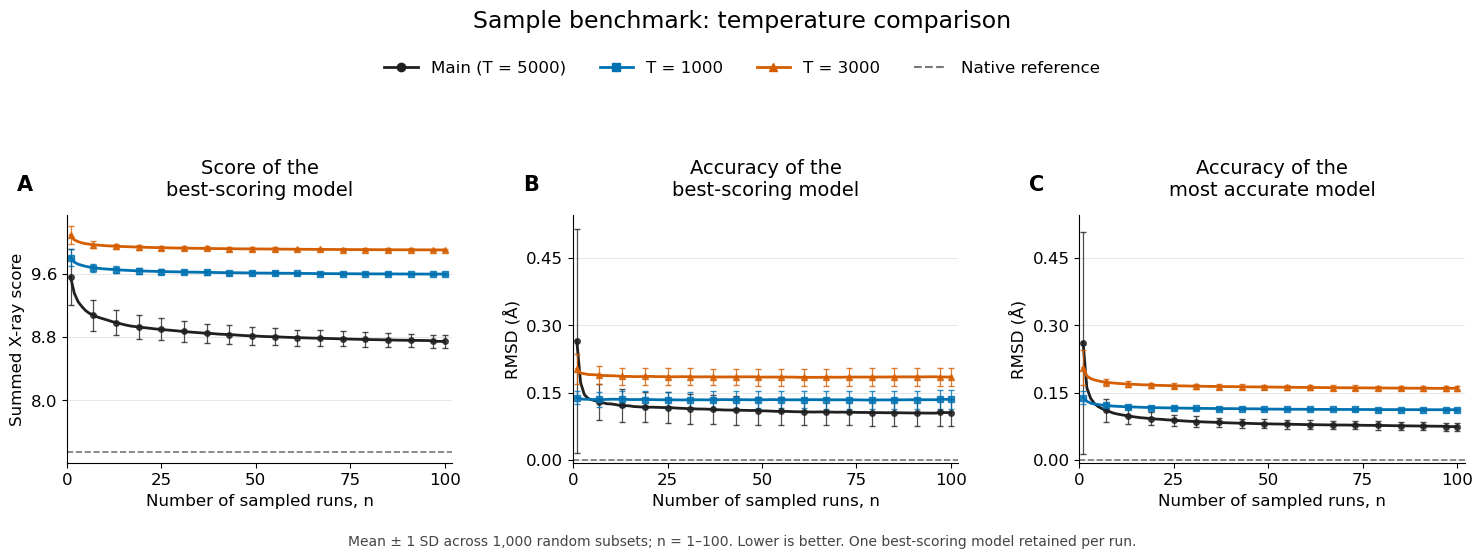

In [4]:
fig = plot_temperature_comparison(plot_max)
save_figure(fig, f"sample_bench_temperature_first_{plot_max}")
plt.show()

## Source and interpretation notes

- Main temperature comes from job 2 of `sample_bench/data/params/277.csv`:
  `s5000,t5000,dA,p1,w0,r0` (two states, two conditions, `w_xray = 0.25`).
  Vipul's temperature labels come from the supplied directory names.
- `sample_bench/scripts/analysis/get_stat_df_per_out.py` defines the retained
  per-run models; `sample_bench/scripts/analysis/sample_volume_bench.py` defines
  the random subsets and population standard deviations. This notebook reuses the
  saved summaries and does not introduce another random draw. The source script
  does not set a random seed.
- RMSD follows the existing analysis: occupancy-weighted mean Cα coordinates,
  averaged across conditions (`src/align_imp.py`). A smaller RMSD means greater accuracy.
- The native score reference is the sum of the two X-ray scores in
  `dev/45_synthetic_native_4/data/csvs/natives_5.csv`; native RMSD is zero.
- **Protocol provenance:** the main dataset is named `277_native_5_ref`, while
  Vipul's folders and source PDB paths have no `_ref` suffix. Separate Vipul
  parameter/refinement metadata is not present locally. These figures compare the
  supplied datasets; the local files alone do not establish that temperature was
  the only protocol difference.